## Apresentação 

Notebook destinado à compreensão do workflow padrão para a classificação de textos utilizando modelos como Naive Bayes, Regressão Logística e SVM. Por mais que atualmente para a identificação da semântica do texto e classificação costuma-se a ser utilizado modelos mais robustos que conseguem compreender semanticamente o texto por meio de vetores e baseados na arquitetura Transformers, a importância desse workflow se constitui como forma de salientar os passos mais salutares do presente contexto, utilizando de um tratamento e de modelos mais simples que atrelados a certos cenários podem ser suficientes para atender à tarefa esperada. Importante frizar que o foco desse notebook não se constitui na elaboração de modelos assertivos, mas tão somente de passar pelo workflow padrão já apresentado. 

### Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [12]:
import itertools
import re
import string
from time import time

import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.feature_extraction import _stop_words
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score

nltk.download("punkt")

from string import punctuation

from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Carregando o dataset

In [3]:
file_path = "data/Full-Economic-News-DFE.csv"

df = pd.read_csv(file_path, encoding="latin1") 

df.head(2)

,_unit_id,_golden,_unit_state,_trusted_judgments,_last_judgment_at,positivity,positivity:confidence,relevance,relevance:confidence,articleid,date,headline,positivity_gold,relevance_gold,text
0,842613455,False,finalized,3,12/5/15 17:48,3.0,0.64,yes,0.64,wsj_398217788,8/14/91,Yields on CDs Fell in the Latest Week,NaN,NaN,NEW YORK -- Yields on most certificates of dep...
1,842613456,False,finalized,3,12/5/15 16:54,NaN,NaN,no,1.00,wsj_399019502,8/21/07,The Morning Brief: White House Seeks to Limit ...,NaN,NaN,The Wall Street Journal Online</br></br>The Mo...


In [4]:
df.shape

(8000, 15)

In [5]:
df["relevance"] = df.relevance.map({"yes": 1, "no": 0})
df = df[["text", "relevance"]]

df.head()

,text,relevance
0,NEW YORK -- Yields on most certificates of dep...,1.0
1,The Wall Street Journal Online</br></br>The Mo...,0.0
2,WASHINGTON -- In an effort to achieve banking ...,0.0
3,The statistics on the enormous costs of employ...,0.0
4,NEW YORK -- Indecision marked the dollar's ton...,1.0


In [6]:
df.shape

(8000, 2)

### Verificando a integridade do dataset

In [7]:
df.isnull().sum()

text         0
relevance    9
dtype: int64

In [8]:
df.duplicated().sum()

6

In [9]:
df = df.dropna()
df = df.drop_duplicates()

In [10]:
df.isnull().sum()

text         0
relevance    0
dtype: int64

In [11]:
df.duplicated().sum()

0

### Text Preprocessing 

In [15]:
stopwords = _stop_words.ENGLISH_STOP_WORDS

print(stopwords)
print(f"Stop words amount in english: {len(stopwords)}")

frozenset({'almost', 'amoungst', 'can', 'find', 'becoming', 'upon', 'less', 'therefore', 'whereas', 'system', 'un', 'although', 'seems', 'be', 'yours', 'her', 'nor', 'sometimes', 'a', 'perhaps', 'so', 'every', 'too', 'is', 'many', 'more', 'whereby', 'first', 'each', 'before', 'with', 'about', 'otherwise', 'fifty', 'move', 'across', 'call', 'hereupon', 'sometime', 'beyond', 'next', 'where', 'both', 'full', 'any', 'sixty', 'must', 'meanwhile', 'fill', 'onto', 'around', 'therein', 'whence', 'hers', 'eg', 'whereafter', 'in', 'last', 'beforehand', 'often', 'either', 'that', 'beside', 'formerly', 'thereafter', 'thick', 'the', 'noone', 'further', 'cry', 'two', 'whenever', 'has', 'enough', 'an', 'amount', 'ten', 'above', 'however', 'bottom', 'him', 'yet', 'nobody', 'etc', 'nowhere', 'once', 'five', 'ever', 'who', 'put', 'yourself', 'anywhere', 'least', 'towards', 'see', 'could', 'whom', 'detail', 'hereby', 'seemed', 'being', 'herself', 'together', 'part', 'inc', 'mill', 'ltd', 'for', 'you', 'a

In [16]:
def clean(doc) -> str:
    """
    Função que limpa os textos presentes no dataset, removendo a tag HTML 
    identificada e mantendo apenas caractéres que não sejam stopwords, pontuações
    ou digitos.  
    """
    doc = doc.replace("<br>", " ")
    doc = "".join([char for char in doc if char not in string.punctuation and not char.isdigit()])
    doc = " ".join([token for token in doc.split() if token not in stopwords])
    return doc

In [17]:
# Tesando a função 
text = "Hi! Is possible back in the time to make things right and don't lose people ?"

clean(doc=text)

'Hi Is possible time make things right dont lose people'

In [18]:
X = df["text"]
y = df["relevance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(6388,) (6388,)
(1597,) (1597,)


In [19]:
vector = CountVectorizer(lowercase=True, preprocessor=clean)

# Correção: só usa fit_transform no treino
X_train_vector = vector.fit_transform(X_train)

# Correção: usa transform no teste
X_test_vector  = vector.transform(X_test)

### Multinomial Naive Bayes

In [20]:
%%time

naive_bayes = MultinomialNB()
naive_bayes.fit(X_train_vector, y_train)

y_pred = naive_bayes.predict(X_test_vector)


CPU times: total: 15.6 ms
Wall time: 25.6 ms


### Logistic Regression 

In [28]:
log_reg = LogisticRegression(class_weight="balanced")

log_reg.fit(X_train_vector, y_train)

y_pred_log_reg = log_reg.predict(X_test_vector)

### Linear SCV

In [30]:
linear_svc = LinearSVC(class_weight="balanced")

linear_svc.fit(X_train_vector, y_train)

y_pred_linear_svc = linear_svc.predict(X_test_vector)

### Avaiando os modelos

In [ ]:
def plot_confusion_matrix(
        cm, 
        classes,
        normalize=False,
        title='Confusion matrix',
        cmap=plt.cm.Blues
    ):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label',fontsize=15)
    plt.xlabel('Predicted label',fontsize=15)

In [37]:
def evaluate_model(test, model_predict) -> float:
    """
    Function that evaluate the models with precision, roc_auc 
    and confusion matrix
    """
    print("F1-score: ", round(f1_score(test, model_predict), 3))

    cnf_matrix = confusion_matrix(test, model_predict)
    plt.figure(figsize=(8,6))
    plot_confusion_matrix(
        cnf_matrix, 
        classes   = ['Not Relevant','Relevant'],
        normalize = True,
        title     = 'Confusion matrix with all features'
    )

    print("ROC_AOC_Score: ", round(roc_auc_score(test, model_predict), 3))

### Naive Bayes Eval

F1-score:  0.352
ROC_AOC_Score:  0.602


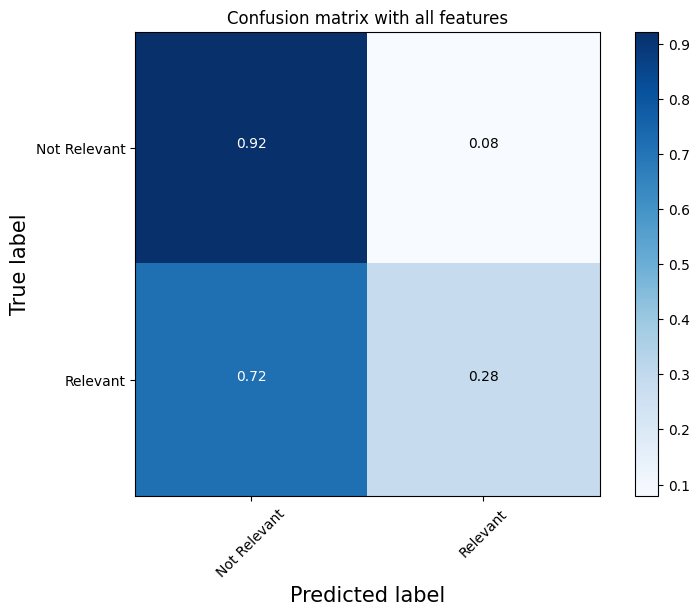

In [38]:
evaluate_model(test=y_test, model_predict=y_pred)

### Logistic Regression Eval

F1-score:  0.384
ROC_AOC_Score:  0.618


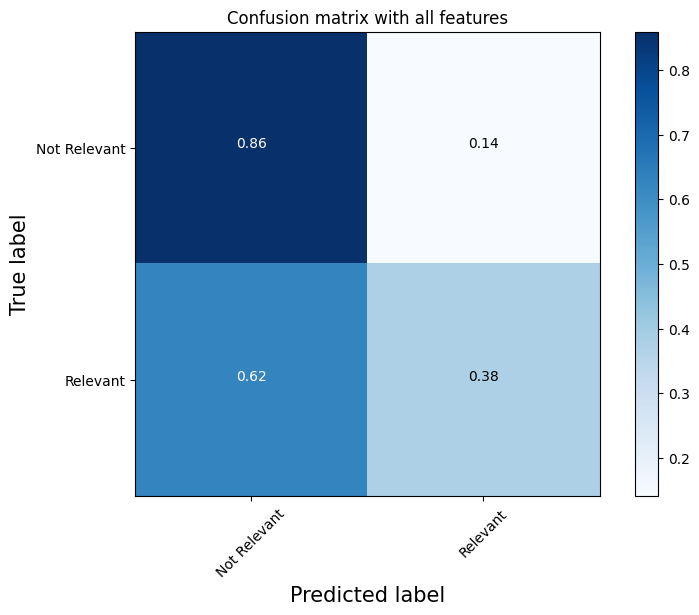

In [39]:
evaluate_model(test=y_test, model_predict=y_pred_log_reg)

### Linear SVC Eval

F1-score:  0.339
ROC_AOC_Score:  0.592


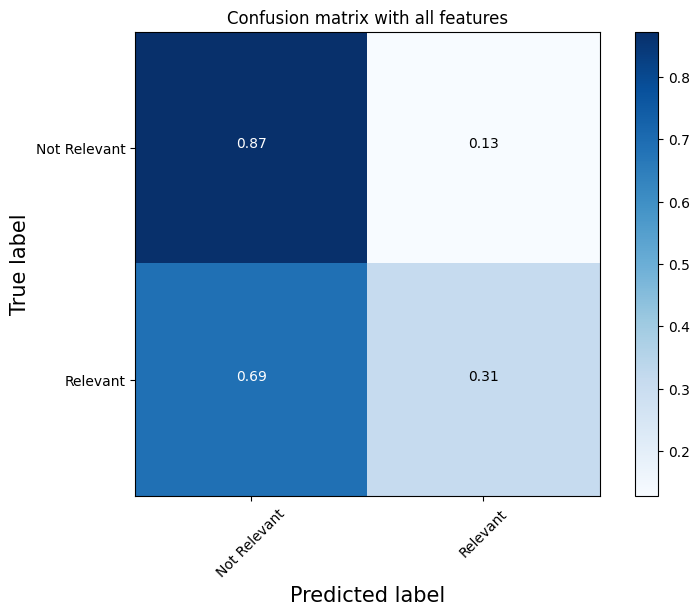

In [40]:
evaluate_model(test=y_test, model_predict=y_pred_linear_svc)